# 第 11 章 · MDP 与价值迭代

订机票四状态：奖励、γ、Bellman 备份。

配套交互演示：[章节网页](../ch11.html)

## 本节目标

- MDP 链
- 价值迭代逐步
- V 收敛 GIF

## 1. MDP 定义

状态序列 S0→S1→S2→S3，每步即时奖励 R(s)，折扣 γ 权衡远期回报。

**Return**

```text
G = R0 + gamma R1 + gamma^2 R2 + ...
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch11"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from rl import *
from common.codelens import print_frames as print_codelens

In [2]:
mdp_demo()

订机票 MDP: 待搜索 → 已比价 → 已下单 → 已确认
即时奖励: [0, 1, 2, 10]   折扣回报 G≈9.8 (网页 ≈9.8)


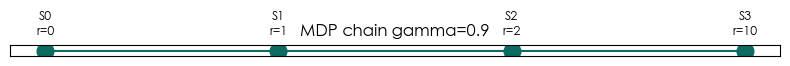

In [3]:
plot_mdp_chain()

## 2. 价值迭代

### 2.1 Bellman 备份

V(s) ← R(s) + γ V(s')，从后向前同步更新。

**Bellman**

```text
V(s) <- R(s) + gamma * V(s')
```

In [4]:
vi_frames = codelens_value_iteration()

In [5]:
print_codelens(vi_frames)

── Step 0 ── 初始化价值
   执行: V=[0,...]
   V = [0.0, 0.0, 0.0, 0.0]

── Step 1 ── 第 1 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [0.0, 1.0, 2.0, 10.0]
   V(S0) = 0.0

── Step 2 ── 第 2 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [0.9, 2.8, 11.0, 10.0]
   V(S0) = 0.9

── Step 3 ── 第 3 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [2.52, 10.9, 11.0, 10.0]
   V(S0) = 2.52

── Step 4 ── 第 4 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [9.81, 10.9, 11.0, 10.0]
   V(S0) = 9.81

── Step 5 ── 第 5 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [9.81, 10.9, 11.0, 10.0]
   V(S0) = 9.81

── Step 6 ── 第 6 轮 Bellman 备份
   执行: V(s) <- R + gamma V(s')
   V = [9.81, 10.9, 11.0, 10.0]
   V(S0) = 9.81



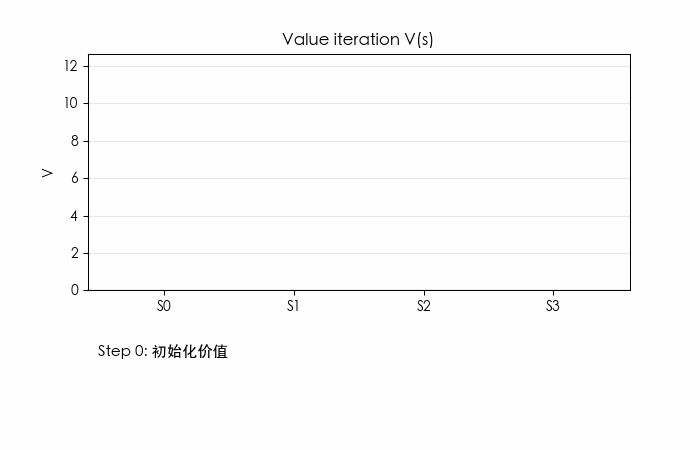

In [6]:
animate_value_iteration()

In [7]:
value_iteration()

收敛 V: [9.81, 10.9, 11.0, 10.0]


[9.81, 10.9, 11.0, 10.0]

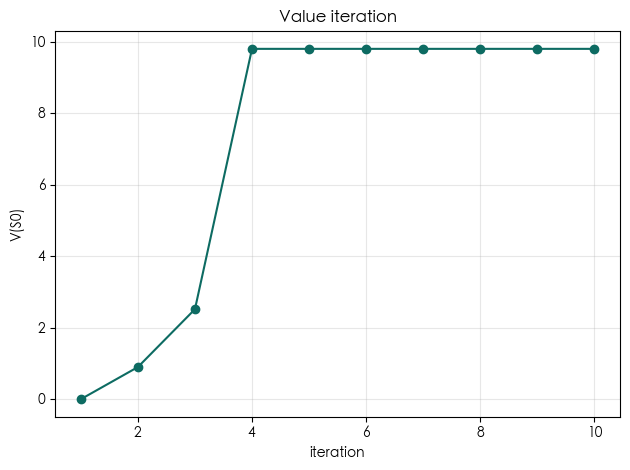

In [8]:
plot_value_iteration()

**思考** · V(S0) 收敛约？

<details><summary>查看答案</summary>

约 9.8，见输出。

</details>

## 小结

长期回报用 γ 折扣；迭代至 V 稳定。对照 [ch11.html](../ch11.html)。

## 练习

1. γ=0 时策略？
2. γ→1 时？